# Individual top-5 MOGA-Phonons dispersion plots by mass and lattice parameter

This notebook loads `dataframe000013.pkl` and `dataframe000014.pkl`, selects the top 5 solutions from each dataframe for each `(mass, a_val)` combination, and generates one publication-quality dispersion figure at a time.

Color convention:

- all dispersions from `dataframe000013` use one fixed color;
- all dispersions from `dataframe000014` use a second fixed color;
- the legend identifies the dataframe/experiment, not the individual solution rank.


In [1]:
from pathlib import Path
from matplotlib.lines import Line2D

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional dependency used only if you need to read band_ga.yaml files directly.
try:
    import yaml
except ImportError:
    yaml = None

# Publication-friendly defaults. Adjust here if you need a different journal layout.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})


## User settings

Edit `DATA_DIR` if your dataframe pickle files are somewhere else. The output folder will be created automatically.

In [54]:
DATA_DIR = Path("/Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes")

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
}

OUTPUT_DIR = DATA_DIR / "individual_top5_dispersion_plots_013_014_publication"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Column names used in the dataframe. Change only if your dataframe uses different names.
mass_col = "mass"
alat_col = "a_val"
fitness_col = "fitness_norm"

# Fixed color mapping by dataframe. Every dispersion from the same dataframe uses the same color.
# These are explicit by design, so the dataset identity is visually consistent across all figures.
DATASET_COLORS = {
    "dataframe000013": "#00FF00",
    "dataframe000014": "#FF0000",
    "dataframe000015": "#0000FF",
    "dataframe000016": "#000000",
}

# Individual curves are semi-transparent so overlap appears darker where solutions agree.
CURVE_ALPHA = 0.70
CURVE_LINEWIDTH = 2.0

# Plot limits used in the paper-style figures.
Y_MIN = 0
Y_MAX = 10
Y_STEP = 2


## Load and combine dataframes

In [55]:
frames = []

for run_id, path in DATAFRAME_FILES.items():
    tmp = pd.read_pickle(path)
    tmp = tmp.copy()
    tmp["run_id"] = run_id
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(df):,} rows")
print(df[["run_id", mass_col, alat_col, fitness_col]].head())
print("\nColumns:")
print(list(df.columns))


Loaded 420,000 rows
            run_id  mass  a_val  fitness_norm
0  dataframe000013  50.0    2.0      1.385453
1  dataframe000013  50.0    2.0      1.374528
2  dataframe000013  50.0    2.0      1.365526
3  dataframe000013  50.0    2.0      1.309002
4  dataframe000013  50.0    2.0      1.308367

Columns:
['simulation', 'generation', 'solution_index', 'rank', 'source', 'timestamp', 'mass', 'a_val', 'system_size', 'alpha0', 'alpha1', 'beta1', 'alpha2', 'beta2', 'fitness', 'fitness1', 'fitness2', 'fitness3', 'fitness_norm', 'sort_by', 'sort_score', 'min_frequency', 'max_frequency', 'num_imaginary', 'stable', 'gamma_frequencies', 'distances', 'qpoints', 'frequencies', 'frequency_vector', 'simulation_path', 'generation_dir', 'solution_dir', 'band_yaml_path', 'run_id']


## Select top 5 solutions from each run for each mass and lattice parameter

This ranks by `fitness_norm` separately within each `(run_id, mass, a_val)` group.

In [56]:
top_k = 1

top = (
    df.sort_values(fitness_col, ascending=False)
      .groupby(["run_id", mass_col, alat_col], as_index=False)
      .head(top_k)
      .reset_index(drop=True)
)

print(f"Selected {len(top):,} rows")
print(top.groupby(["run_id", mass_col, alat_col]).size().head(10))


Selected 168 rows
run_id           mass  a_val
dataframe000013  50.0  2.0      1
                       2.2      1
                       2.4      1
                       2.6      1
                       2.8      1
                       3.0      1
                       3.2      1
                 60.0  2.0      1
                       2.2      1
                       2.4      1
dtype: int64


## List available combinations

In [57]:
combinations = (
    top[[mass_col, alat_col]]
    .drop_duplicates()
    .sort_values([mass_col, alat_col])
    .reset_index(drop=True)
)

print(f"Available mass/lattice combinations: {len(combinations)}")
display(combinations)


Available mass/lattice combinations: 42


,mass,a_val
0,50.0,2.0
1,50.0,2.2
2,50.0,2.4
3,50.0,2.6
4,50.0,2.8
5,50.0,3.0
6,50.0,3.2
7,60.0,2.0
8,60.0,2.2
9,60.0,2.4


## Helper functions

The main plotting function first tries to use array-valued columns from the dataframe. If those are absent, it falls back to reading `band_ga.yaml` files.

In [58]:
def fmt_sig(x, sig=4):
    """Compact formatting for plot titles and filenames."""
    return f"{float(x):.{sig}g}"


def safe_float_token(x):
    """Make a float safe for filenames."""
    return str(fmt_sig(x)).replace("-", "m").replace(".", "p")


def get_bcc_tick_positions(x):
    """Return tick positions for Gamma-H-P-Gamma-N using four equal path segments."""
    x = np.asarray(x)
    idx = [0, len(x)//4, len(x)//2, 3*len(x)//4, len(x)-1]
    tick_positions = [x[i] for i in idx]
    tick_labels = [r"$\Gamma$", "H", "P", r"$\Gamma$", "N"]
    return tick_positions, tick_labels


def _first_existing_column(row, candidates):
    for col in candidates:
        if col in row.index and row[col] is not None:
            try:
                if pd.notna(row[col]) is False:
                    continue
            except Exception:
                pass
            return col
    return None


def get_dispersion_from_dataframe_row(row):
    """
    Return x, freqs from array-valued dataframe columns.

    Expected possibilities:
      distances/distance/path_distances/q_distances
      frequencies/frequency/phonon_frequencies/band_frequencies

    freqs may be stored as shape (n_q, n_branch) or (n_branch, n_q).
    """
    distance_col = _first_existing_column(
        row,
        ["distances", "distance", "path_distances", "q_distances", "band_distances"],
    )
    freq_col = _first_existing_column(
        row,
        ["frequencies", "frequency", "phonon_frequencies", "band_frequencies", "freqs"],
    )

    if distance_col is None or freq_col is None:
        raise KeyError("Could not find distance/frequency array columns in dataframe row.")

    x = np.asarray(row[distance_col], dtype=float)
    freqs = np.asarray(row[freq_col], dtype=float)

    if freqs.ndim != 2:
        raise ValueError(f"Expected a 2D frequency array, got shape {freqs.shape}.")

    # Ensure shape is (n_q, n_branch)
    if freqs.shape[0] != len(x) and freqs.shape[1] == len(x):
        freqs = freqs.T

    return x, freqs


def get_yaml_path(row):
    """Infer the band_ga.yaml path from common dataframe path columns."""
    possible_path_cols = [
        "yaml_path", "band_yaml_path", "band_ga_yaml", "filepath", "file_path", "path",
    ]

    for col in possible_path_cols:
        if col in row.index and row[col] is not None:
            try:
                if pd.notna(row[col]) is False:
                    continue
            except Exception:
                pass
            return Path(row[col])

    if "simulation_path" in row.index and "generation" in row.index:
        gen = int(row["generation"])
        return Path(row["simulation_path"]) / "phonon_generations" / f"generation_{gen:06d}" / "band_ga.yaml"

    if "sim_path" in row.index and "generation" in row.index:
        gen = int(row["generation"])
        return Path(row["sim_path"]) / "phonon_generations" / f"generation_{gen:06d}" / "band_ga.yaml"

    raise ValueError("Could not infer band_ga.yaml path from dataframe row.")


def load_phonopy_band_yaml(yaml_path):
    """Load x positions and frequency bands from a Phonopy-style band YAML file."""
    if yaml is None:
        raise ImportError("pyyaml is required to read YAML files. Install with: pip install pyyaml")

    yaml_path = Path(yaml_path)
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    phonons = data["phonon"]
    x = np.array([p.get("distance", i) for i, p in enumerate(phonons)], dtype=float)
    freqs = np.array([[band["frequency"] for band in p["band"]] for p in phonons], dtype=float)
    return x, freqs


def get_dispersion(row):
    """Use dataframe arrays if available; otherwise read the corresponding band_ga.yaml."""
    try:
        return get_dispersion_from_dataframe_row(row)
    except Exception:
        yaml_path = get_yaml_path(row)
        return load_phonopy_band_yaml(yaml_path)


## Plot one selected mass/lattice-parameter combination

Change `SELECTED_MASS` and `SELECTED_A_VAL` to generate a different individual plot. The default plot saves both PNG and PDF versions.


In [59]:
SELECTED_MASS = float(combinations.iloc[0][mass_col])
SELECTED_A_VAL = float(combinations.iloc[0][alat_col])

print(f"Selected m = {SELECTED_MASS} amu, a = {SELECTED_A_VAL} Å")


Selected m = 50.0 amu, a = 2.0 Å


Saved:
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2.png
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2.pdf


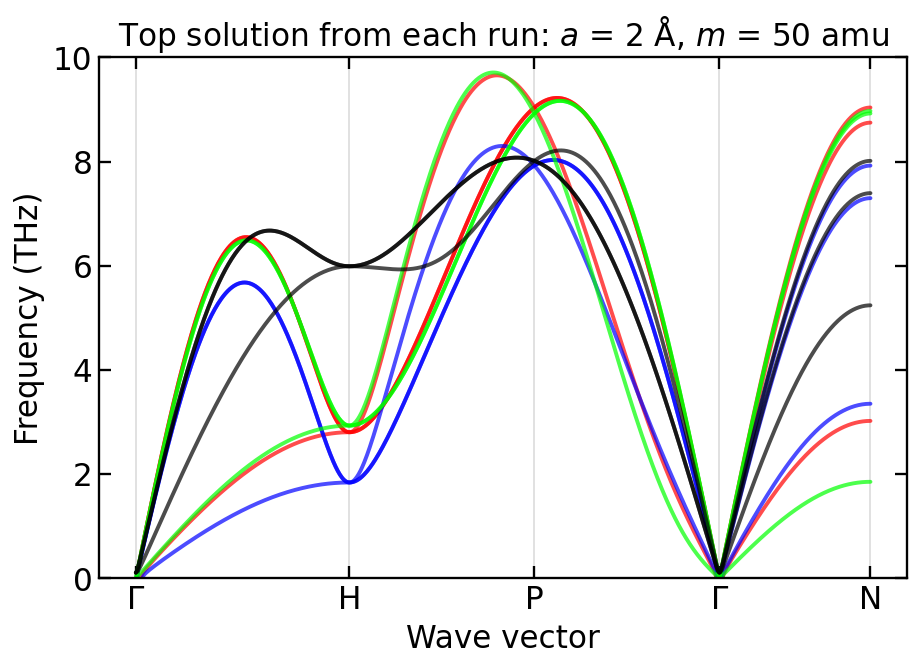

In [60]:
def plot_combination(mass, alat, save=True, show=True, output_formats=("png", "pdf")):
    """
    Plot top-k dispersions from each dataframe for one (mass, a_val) pair.

    All curves from a given dataframe have the same color. The legend contains one entry per dataframe.
    """
    sub = top[
        np.isclose(top[mass_col].astype(float), float(mass))
        & np.isclose(top[alat_col].astype(float), float(alat))
    ].copy()

    if sub.empty:
        raise ValueError(f"No rows found for mass={mass}, a_val={alat}")

    fig, ax = plt.subplots(figsize=(6.8, 5.0))

    last_x = None
    plotted_run_ids = set()

    for _, row in sub.iterrows():
        x, freqs = get_dispersion(row)
        last_x = x

        run_id = row["run_id"]
        color = DATASET_COLORS.get(run_id, "black")

        for branch in range(freqs.shape[1]):
            ax.plot(
                x,
                freqs[:, branch],
                color=color,
                alpha=CURVE_ALPHA,
                linewidth=CURVE_LINEWIDTH,
                solid_capstyle="round",
            )

        plotted_run_ids.add(run_id)

    if last_x is not None:
        tick_positions, tick_labels = get_bcc_tick_positions(last_x)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        for xpos in tick_positions:
            ax.axvline(xpos, color="0.85", linewidth=0.8, zorder=0)

    ax.axhline(0, color="0.25", linewidth=0.8, zorder=0)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_yticks(np.arange(Y_MIN, Y_MAX + 0.1, Y_STEP))
    ax.set_ylabel("Frequency (THz)")
    ax.set_xlabel("Wave vector")
    #ax.set_title(f"Top {top_k} solutions: $a$ = {fmt_sig(alat)} Å, $m$ = {fmt_sig(mass)} amu")
    ax.set_title(f"Top solution from each run: $a$ = {fmt_sig(alat)} Å, $m$ = {fmt_sig(mass)} amu")

    # Publication-style mirrored axes.
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=16,
        length=6,
        width=1.2,
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    # Legend with one handle per dataframe, independent of how many curves were plotted.
    legend_handles = [
        Line2D([0], [0], color=DATASET_COLORS.get(run_id, "black"), lw=2.5, label=run_id)
        for run_id in sorted(plotted_run_ids)
    ]
    #ax.legend(handles=legend_handles, frameon=False, loc="best")

    fig.tight_layout()

    saved_paths = []
    if save:
        stem = f"top{top_k}_m_{safe_float_token(mass)}_a_{safe_float_token(alat)}"
        for ext in output_formats:
            outpath = OUTPUT_DIR / f"{stem}.{ext}"
            fig.savefig(outpath, bbox_inches="tight")
            saved_paths.append(outpath)
        print("Saved:")
        for path in saved_paths:
            print(f"  {path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax, saved_paths


fig, ax, saved_paths = plot_combination(SELECTED_MASS, SELECTED_A_VAL, save=True, show=True)


## Generate and save every mass/lattice-parameter combination individually

Run this cell when you want one PNG and one PDF file per combination. The figures are saved to `OUTPUT_DIR`.


In [61]:
for _, combo in combinations.iterrows():
    plot_combination(
        mass=combo[mass_col],
        alat=combo[alat_col],
        save=True,
        show=False,
        output_formats=("png", "pdf"),
    )

print(f"Done. Individual plots saved in: {OUTPUT_DIR}")


Saved:
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2.png
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2.pdf
Saved:
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2p2.png
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2p2.pdf
Saved:
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2p4.png
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2p4.pdf
Saved:
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/individual_top5_dispersion_plots_013_014_publication/top1_m_50_a_2p6.png
  /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/i

## Optional: inspect the selected rows for one combination

In [43]:
selected_rows = top[
    np.isclose(top[mass_col].astype(float), float(SELECTED_MASS))
    & np.isclose(top[alat_col].astype(float), float(SELECTED_A_VAL))
].copy()

cols_to_show = [
    c for c in [
        "run_id", mass_col, alat_col, "generation", "solution_index", "rank",
        "alpha0", "alpha1", "beta1", "alpha2", "beta2",
        "fitness1", "fitness2", "fitness3", fitness_col,
    ]
    if c in selected_rows.columns
]

display(selected_rows[cols_to_show].sort_values(["run_id", fitness_col], ascending=[True, False]))


,run_id,mass,a_val,generation,solution_index,rank,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm
144,dataframe000013,50.0,2.0,355,4,4,8.589455,-0.110056,0.985794,-0.000223,-1.927148,1.0,0.999969,0.959208,1.708806
128,dataframe000014,50.0,2.0,410,17,2,8.762220,-0.100837,0.861796,-0.001265,-1.988821,1.0,0.997720,0.968249,1.712586
142,dataframe000015,50.0,2.0,441,30,3,6.598133,-0.043472,0.537544,-0.001001,-1.562507,1.0,0.998327,0.961388,1.709071
165,dataframe000016,50.0,2.0,463,41,3,8.407251,-0.458897,-0.347980,0.000729,-1.183750,1.0,0.997476,0.933149,1.692845
